# 숙제 3

데이터과학 입문

한성훈 (서울대학교 사범대학)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

`NHANES` 자료에서 20세 이상인 사람들을 대상으로 **현재 흡연 여부**를
예측하는 로지스틱 회귀 모형을 적합한다.

핵심 데이터 가공은 반응변수 구성이다. `SmokeNow`(현재 흡연 여부)는 평생
담배를 100개비 이상 피운 적이 있는 사람(`Smoke100 == "Yes"`)에 대해서만
조사되므로, 한 번도 피우지 않은 사람(`Smoke100 == "No"`)은 `SmokeNow`가
결측(`NA`)으로 남는다. 이들은 정의상 현재 비흡연자이므로 `0`으로
재코딩해야 한다. 즉 `current_smoker = 1` iff `SmokeNow == "Yes"`, 그
외(`SmokeNow == "No"` 또는 `Smoke100 == "No"`)는 모두 `0`이다.

예측변수로는 나이(`Age`), 성별(`Gender`), 인종(`Race1`),
교육수준(`Education`), 빈곤지수(`Poverty`), 체질량지수(`BMI`), 신체활동
여부(`PhysActive`)를 사용한다.

## R

``` r
library(tidyverse)
library(NHANES)
library(broom)

# 20세 이상 + Smoke100이 관측된 사람만 사용
# Smoke100 == "No"인 사람은 SmokeNow가 NA이며 현재 비흡연자(0)로 재코딩됨
nhanes_smoke <- NHANES %>%
    filter(Age >= 20, !is.na(Smoke100)) %>%
    mutate(current_smoker = if_else(SmokeNow == "Yes" & !is.na(SmokeNow), 1L, 0L)) %>%
    select(current_smoker, Age, Gender, Race1, Education, Poverty, BMI, PhysActive) %>%
    drop_na()

cat("표본 수:", nrow(nhanes_smoke),
    "| 현재 흡연율:", round(mean(nhanes_smoke$current_smoker), 3), "\n")
```

    표본 수: 6632 | 현재 흡연율: 0.2 

``` r
# 로지스틱 회귀 적합
fit_smoke <- glm(
    current_smoker ~ Age + Gender + Race1 + Education + Poverty + BMI + PhysActive,
    data = nhanes_smoke, family = binomial
)

# 오즈비(exponentiate)와 95% 신뢰구간
tidy(fit_smoke, exponentiate = TRUE, conf.int = TRUE) %>%
    select(term, OR = estimate, conf.low, conf.high, p.value) %>%
    knitr::kable(digits = 3, caption = "흡연 예측 로지스틱 회귀: 오즈비와 95% 신뢰구간")
```

| term                    |    OR | conf.low | conf.high | p.value |
|:------------------------|------:|---------:|----------:|--------:|
| (Intercept)             | 6.114 |    3.699 |    10.114 |   0.000 |
| Age                     | 0.976 |    0.972 |     0.980 |   0.000 |
| Gendermale              | 1.442 |    1.267 |     1.642 |   0.000 |
| Race1Hispanic           | 0.558 |    0.399 |     0.774 |   0.001 |
| Race1Mexican            | 0.375 |    0.274 |     0.511 |   0.000 |
| Race1White              | 1.141 |    0.935 |     1.397 |   0.200 |
| Race1Other              | 0.965 |    0.711 |     1.305 |   0.819 |
| Education9 - 11th Grade | 1.496 |    1.110 |     2.028 |   0.009 |
| EducationHigh School    | 0.916 |    0.682 |     1.236 |   0.561 |
| EducationSome College   | 0.703 |    0.523 |     0.951 |   0.021 |
| EducationCollege Grad   | 0.310 |    0.222 |     0.434 |   0.000 |
| Poverty                 | 0.843 |    0.806 |     0.882 |   0.000 |
| BMI                     | 0.959 |    0.949 |     0.969 |   0.000 |
| PhysActiveYes           | 0.583 |    0.508 |     0.670 |   0.000 |

흡연 예측 로지스틱 회귀: 오즈비와 95% 신뢰구간
{quarto-postprocess="true"}

``` r
cat("AIC:", round(AIC(fit_smoke), 1),
    "| Null deviance:", round(fit_smoke$null.deviance, 1),
    "| Residual deviance:", round(fit_smoke$deviance, 1), "\n")
```

    AIC: 5918.5 | Null deviance: 6641.8 | Residual deviance: 5890.5 

## Python

``` python
import matplotlib.pyplot as plt
```

``` python
import polars as pl
import numpy as np
import statsmodels.formula.api as smf
from plotnine import *

# NHANES는 Python 패키지가 없어 R 객체를 그대로 가져온다
NHANES_py = pl.from_pandas(r.NHANES)

nhanes_smoke = (
    NHANES_py
    .filter((pl.col("Age") >= 20) & pl.col("Smoke100").is_not_null())
    .with_columns(
        pl.when(pl.col("SmokeNow") == "Yes").then(1).otherwise(0).alias("current_smoker")
    )
    .select(["current_smoker", "Age", "Gender", "Race1",
             "Education", "Poverty", "BMI", "PhysActive"])
    .drop_nulls()
).to_pandas()

print(f"표본 수: {len(nhanes_smoke)} | "
      f"현재 흡연율: {nhanes_smoke['current_smoker'].mean():.3f}")
```

    표본 수: 6632 | 현재 흡연율: 0.200

``` python
fit_smoke = smf.logit(
    "current_smoker ~ Age + Gender + Race1 + Education + Poverty + BMI + PhysActive",
    data=nhanes_smoke
).fit(disp=0)

# 오즈비와 95% 신뢰구간
or_table = np.exp(fit_smoke.params).to_frame("OR")
or_table[["conf_low", "conf_high"]] = np.exp(fit_smoke.conf_int())
or_table["p_value"] = fit_smoke.pvalues
print(or_table.round(3))
```

                                    OR  conf_low  conf_high  p_value
    Intercept                    9.211     6.175     13.741    0.000
    Gender[T.female]             0.693     0.609      0.789    0.000
    Race1[T.Mexican]             0.329     0.250      0.432    0.000
    Race1[T.Hispanic]            0.489     0.365      0.656    0.000
    Race1[T.Other]               0.846     0.657      1.090    0.196
    Race1[T.Black]               0.877     0.717      1.072    0.200
    Education[T.Some College]    0.768     0.649      0.910    0.002
    Education[T.College Grad]    0.339     0.272      0.421    0.000
    Education[T.9 - 11th Grade]  1.634     1.338      1.995    0.000
    Education[T.8th Grade]       1.092     0.811      1.470    0.561
    PhysActive[T.Yes]            0.583     0.508      0.670    0.000
    Age                          0.976     0.972      0.980    0.000
    Poverty                      0.843     0.806      0.882    0.000
    BMI                          0.959     0.949      0.969    0.000

``` python
print(f"\nAIC: {fit_smoke.aic:.1f}")
```


    AIC: 5918.5

- **데이터 해석**:
  - 표본 6,632명의 현재 흡연율은 약 20%이다.
  - **나이**: 오즈비 0.976으로, 나이가 한 살 많아질수록 현재 흡연 오즈가
    약 2.4%씩 감소한다. 고령층일수록 금연했거나 흡연 관련 사망으로
    표본에서 빠졌을 가능성을 반영한다.
  - **성별**: 남성의 현재 흡연 오즈가 여성의 약 1.44배로 유의하게 높다.
  - **교육수준**: 대졸자(College Grad)의 흡연 오즈는 기준 집단의 약
    0.31배로, 교육수준이 높을수록 흡연 확률이 뚜렷하게 낮다.
  - **빈곤지수(Poverty)**: 값이 클수록(소득이 높을수록) 오즈비 0.843으로
    흡연 확률이 감소한다.
  - **신체활동**: 활동적인 사람의 흡연 오즈가 약 0.58배로 낮아, 건강
    행동들이 함께 나타나는 경향을 보인다.
  - **BMI**: 오즈비 0.959로 BMI가 높을수록 흡연 확률이 약간 낮은데,
    흡연이 체중을 억제하는 경향과 부합한다.
- **R-Python 비교**:
  - `NHANES` 패키지는 Python용이 없으므로 `r.NHANES`로 R 데이터를
    Python에 직접 넘겼다.
  - R은 `glm(family = binomial)`, Python은 `statsmodels`의 `logit`으로
    동일한 모형을 적합했고 **AIC가 5918.5로 정확히 일치**한다.
  - 두 언어의 오즈비 표가 달라 보이는 것은 범주형 변수의 기준
    범주(reference level)가 다르기 때문이다. 예를 들어 R은 성별 기준이
    `female`이라 `male`의 OR이 1.44로 나오고, Python(`statsmodels`)은
    기준이 `male`이라 `female`의 OR이 0.693(≈1/1.44)으로 나온다. 기준만
    바뀌었을 뿐 두 모형은 수학적으로 동일하다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

`Teams` 자료에서 2010–2025년(코로나 시즌인 2020년 제외)을 추출한다.
여기서 득점 $RS$는 `R` 열, 실점은 `RA` 열이며, 승률은 $WPct = W/(W+L)$로
계산한다. 관측단위는 팀-연도(team-season)이다.

**모형 연결.** Bill James 식의 양변에 로짓을 취하면 모형 (1)과 (2)가
사실상 같은 모수를 추정함을 알 수 있다.
$$\text{logit}(WPct) = \log\frac{WPct}{1-WPct}
= \log\frac{RS^k}{RA^k} = k\,\log\!\left(\frac{RS}{RA}\right).$$
즉 $WPct$를 반응변수로 하고 $\log(RS/RA)$를 유일한 설명변수로 하는
**절편 없는** 로지스틱 회귀의 기울기 $\beta_1$이 곧 Bill James 지수
$k$이다. 또한 $\log(RS/RA) = \log(RS) - \log(RA)$이므로, 4항처럼
$\log(RS)$와 $\log(RA)$를 따로 넣으면 두 계수는 크기가 $k$로 같고 부호만
반대($+k,\,-k$)가 되어야 한다.

## R

``` r
library(Lahman)

# 2010-2025, 2020(코로나) 제외. RS=R(득점), WPct=W/(W+L)
teams <- Teams %>%
    filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
    mutate(
        RS = R,
        WPct = W / (W + L),
        games = W + L,
        logRSRA = log(RS / RA)
    ) %>%
    select(yearID, teamID, W, L, RS, RA, WPct, games, logRSRA)

cat("팀-시즌 관측치 수:", nrow(teams), "\n")
```

    팀-시즌 관측치 수: 450 

``` r
# --- (1) 비선형 최소제곱으로 Bill James 지수 k 추정 ---
nls_fit <- nls(WPct ~ 1 / (1 + (RA / RS)^k), data = teams, start = list(k = 2))
cat("\n[ (1) NLS 적합 ]\n")
```


    [ (1) NLS 적합 ]

``` r
print(summary(nls_fit)$coefficients)
```

      Estimate Std. Error  t value      Pr(>|t|)
    k 1.752794 0.02934518 59.73023 9.158454e-216

``` r
cat("k의 95% 신뢰구간:\n")
```

    k의 95% 신뢰구간:

``` r
print(confint(nls_fit))
```

        2.5%    97.5% 
    1.695234 1.810559 

``` r
# --- (2) 절편 없는 로지스틱 회귀 (beta1 = k) ---
# WPct는 비율이므로 경기수(games)를 가중치로 사용
glm_fit <- glm(WPct ~ 0 + logRSRA, data = teams,
               family = binomial, weights = games)
cat("\n[ (2) 절편 없는 로지스틱 적합 ]\n")
```


    [ (2) 절편 없는 로지스틱 적합 ]

``` r
print(summary(glm_fit)$coefficients)
```

            Estimate Std. Error  z value      Pr(>|z|)
    logRSRA 1.753203 0.04561729 38.43287 3.952525e-323

``` r
cat("beta1의 95% 신뢰구간:\n")
```

    beta1의 95% 신뢰구간:

``` r
print(confint(glm_fit))
```

       2.5 %   97.5 % 
    1.663879 1.842698 

## Python

``` python
import pylahman
import statsmodels.api as sm
from scipy.optimize import curve_fit

Teams_py = pl.from_pandas(pylahman.Teams()).rename({"2B": "X2B", "3B": "X3B"})

teams = (
    Teams_py
    .filter((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025)
            & (pl.col("yearID") != 2020))
    .with_columns(
        RS=pl.col("R"),
        WPct=pl.col("W") / (pl.col("W") + pl.col("L")),
        games=pl.col("W") + pl.col("L"),
    )
    .with_columns(logRSRA=(pl.col("RS") / pl.col("RA")).log())
).to_pandas()

print("팀-시즌 관측치 수:", len(teams))
```

    팀-시즌 관측치 수: 420

``` python
# (1) 비선형 최소제곱
def bill_james(X, k):
    RS, RA = X
    return 1.0 / (1.0 + (RA / RS) ** k)

popt, pcov = curve_fit(bill_james, (teams["RS"].values, teams["RA"].values),
                       teams["WPct"].values, p0=[2.0])
k_hat, k_se = popt[0], np.sqrt(np.diag(pcov))[0]
print(f"\n[ (1) NLS ] k = {k_hat:.4f}, "
      f"95% CI = [{k_hat - 1.96 * k_se:.3f}, {k_hat + 1.96 * k_se:.3f}]")
```


    [ (1) NLS ] k = 1.7610, 95% CI = [1.702, 1.820]

``` python
# (2) 절편 없는 로지스틱 (freq_weights로 경기수 반영)
glm_fit = smf.glm("WPct ~ 0 + logRSRA", data=teams,
                  family=sm.families.Binomial(),
                  freq_weights=teams["games"].values).fit()
ci = glm_fit.conf_int().loc["logRSRA"]
print(f"[ (2) logistic ] beta1 = {glm_fit.params['logRSRA']:.4f}, "
      f"95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]")
```

    [ (2) logistic ] beta1 = 1.7608, 95% CI = [1.668, 1.853]

**(1)·(2) 비교**: NLS의 $k$와 로지스틱의 $\beta_1$이 거의 같다.

| 방법                               | 추정치 | 95% 신뢰구간     |
|------------------------------------|--------|------------------|
| \(1\) 비선형 최소제곱 $k$          | 1.753  | \[1.695, 1.811\] |
| \(2\) 절편 없는 로지스틱 $\beta_1$ | 1.753  | \[1.664, 1.843\] |

위 표대로 두 점추정치가 사실상 일치한다. 두 모형이 같은 모수를 다른
방식으로 추정하기 때문이다. (1)은 승률 자체의 제곱오차를 최소화하고,
(2)는 이항 가능도를 최대화한다는 차이만 있어 신뢰구간 폭이 약간 다르다.
예측 WPct는 선형예측치 $\hat\eta = \hat\beta_1 \cdot \log(RS/RA)$에
sigmoid를 적용한 $\hat{WPct} = \sigma(\hat\eta) = 1/(1+e^{-\hat\eta})$로
계산된다.

**(3) 모형 진단**

## R

``` r
# (i) Residual deviance를 카이제곱 분포와 비교
rd <- glm_fit$deviance
df_resid <- glm_fit$df.residual
cat("Residual deviance =", round(rd, 1), "  df =", df_resid,
    "  dev/df =", round(rd / df_resid, 3), "\n")
```

    Residual deviance = 180.3   df = 449   dev/df = 0.401 

``` r
cat("p-value (H0: 적합 적절) =",
    round(pchisq(rd, df_resid, lower.tail = FALSE), 3), "\n")
```

    p-value (H0: 적합 적절) = 1 

``` r
# 진단용 데이터: 선형예측치(eta), deviance residual, 예측 WPct
diag_df <- teams %>%
    mutate(
        eta = predict(glm_fit, type = "link"),
        dev_resid = residuals(glm_fit, type = "deviance"),
        pred_WPct = predict(glm_fit, type = "response")
    )

# (ii) Deviance residuals vs 선형예측치(eta)
ggplot(diag_df, aes(x = eta, y = dev_resid)) +
    geom_point(alpha = 0.4) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
    geom_smooth(method = "loess", se = FALSE, color = "steelblue") +
    labs(title = "Deviance Residuals vs Linear Predictor",
         x = expression(eta), y = "Deviance residual") +
    theme_minimal()
```

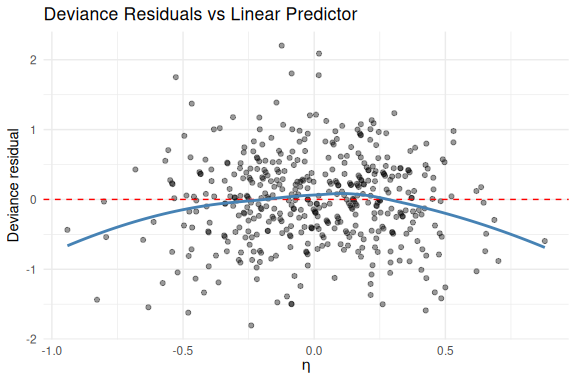

``` r
# (iii) 관측 WPct vs 예측 WPct
ggplot(diag_df, aes(x = pred_WPct, y = WPct)) +
    geom_point(alpha = 0.4) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
    labs(title = "Observed vs Predicted WPct",
         x = "Predicted WPct", y = "Observed WPct") +
    theme_minimal()
```

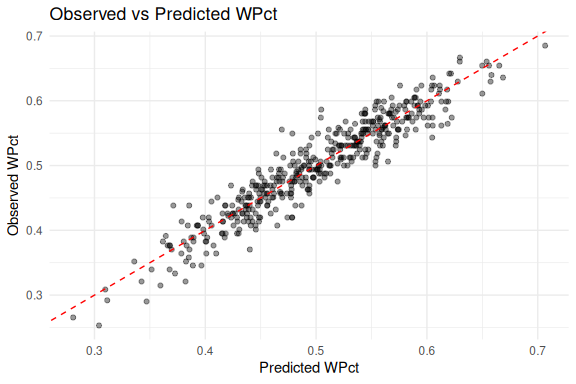

## Python

``` python
# 점추정·예측은 (2)의 모형과 동일하므로 그대로 사용한다
teams_diag = teams.copy()
teams_diag["eta"] = glm_fit.predict(teams, linear=True)
teams_diag["pred_WPct"] = glm_fit.predict(teams)
teams_diag["dev_resid"] = glm_fit.resid_deviance

# (ii) Deviance residuals vs 선형예측치
(
    ggplot(teams_diag, aes(x="eta", y="dev_resid"))
    + geom_point(alpha=0.4)
    + geom_hline(yintercept=0, linetype="dashed", color="red")
    + geom_smooth(method="lowess", se=False, color="steelblue")
    + labs(title="Deviance Residuals vs Linear Predictor",
           x="eta", y="Deviance residual")
    + theme_minimal()
).show()
```

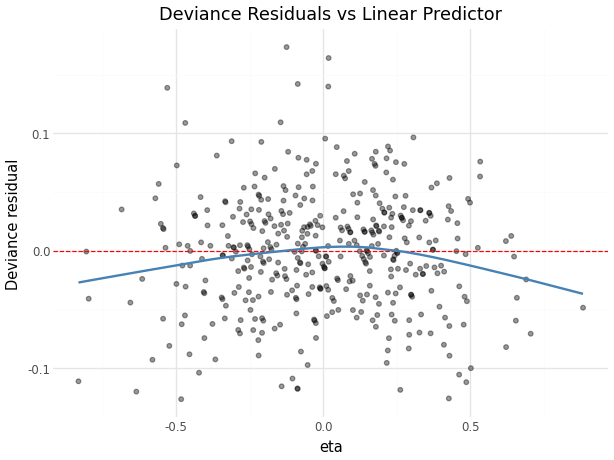

``` python
# (iii) 관측 WPct vs 예측 WPct
(
    ggplot(teams_diag, aes(x="pred_WPct", y="WPct"))
    + geom_point(alpha=0.4)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="red")
    + labs(title="Observed vs Predicted WPct",
           x="Predicted WPct", y="Observed WPct")
    + theme_minimal()
).show()
```

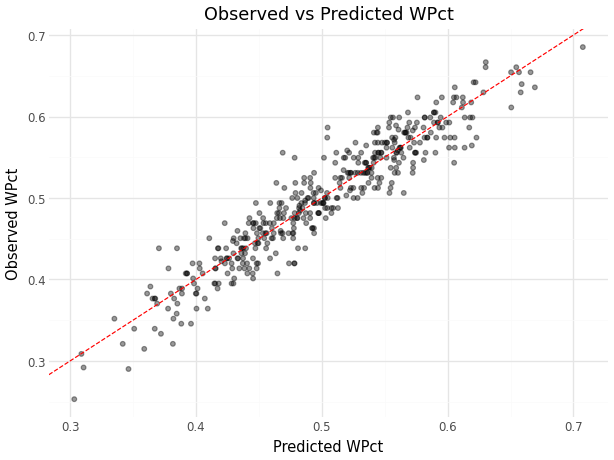

**(4) `WPct ~ log(RA) + log(RS)` (절편 없음)**

## R

``` r
glm_fit4 <- glm(WPct ~ 0 + I(log(RA)) + I(log(RS)), data = teams,
                family = binomial, weights = games)
print(summary(glm_fit4)$coefficients)
```

                Estimate Std. Error   z value      Pr(>|z|)
    I(log(RA)) -1.753561 0.04562946 -38.43047 3.952525e-323
    I(log(RS))  1.753153 0.04561853  38.43072 3.952525e-323

``` r
cat("\n계수 절대값:", round(abs(coef(glm_fit4)), 3),
    " (둘 다 k≈1.75에 근접, 부호는 +/-)\n")
```


    계수 절대값: 1.754 1.753  (둘 다 k≈1.75에 근접, 부호는 +/-)

## Python

``` python
teams["logRA"] = np.log(teams["RA"])
teams["logRS"] = np.log(teams["RS"])
glm_fit4 = smf.glm("WPct ~ 0 + logRA + logRS", data=teams,
                   family=sm.families.Binomial(),
                   freq_weights=teams["games"].values).fit()
print(glm_fit4.params.round(3))
```

    logRA   -1.761
    logRS    1.761
    dtype: float64

- **데이터 해석**:
  - **(1)·(2)**: Bill James 지수 $k$의 점추정치는 약
    **1.75**이다(NLS·로지스틱 모두). 이는 야구에서 흔히 인용되는
    “피타고리안 지수” 1.8~2와 유사한 값이다. 신뢰구간이 1을 한참
    넘으므로 득점 대비 실점 비율이 승률에 강하게 비선형으로 작용함을
    뜻한다.
  - **(3-i)**: Residual deviance가 180.3, 자유도 449로
    `dev/df ≈ 0.40`이다. 카이제곱 분포 기준 p-value가 1에 가까워
    과대산포(overdispersion)는 없고 모형이 데이터를 잘 설명한다. (오히려
    deviance가 자유도보다 작아 약간의 과소산포 경향이 있는데, 이는
    승률이 매우 안정적인 통계량이기 때문이다.)
  - **(3-ii)**: deviance 잔차가 선형예측치 $\eta$에 대해 0을 중심으로
    뚜렷한 패턴 없이 흩어져 있어, 체계적 편향이나 비선형 누락이 없음을
    보여준다.
  - **(3-iii)**: 관측 WPct와 예측 WPct가 45도 대각선 주위에 밀집해 있어
    예측력이 좋다.
  - **(4)**: $\log(RS)$ 계수는 약 **+1.75**, $\log(RA)$ 계수는 약
    **−1.75**로, 크기가 둘 다 $k$와 거의 같고 부호만 반대다. 이는 모형이
    $k\log(RS)-k\log(RA)=k\log(RS/RA)$로 환원되어 (2)와 동일한 모형임을
    실증한다. 즉 a·b·d항이 모두 같은 $k$를 추정한다.
- **R-Python 비교**:
  - NLS는 R의 `nls()`, Python의 `scipy.optimize.curve_fit`을 사용했고
    $k$ 점추정치가 1.753으로 일치한다.
  - 로지스틱은 R `glm(weights=games)`, Python
    `statsmodels.glm(freq_weights=games)`로 적합했고 계수가 일치한다.
    다만 `statsmodels`의 `freq_weights`는 가중치를 관측 빈도로 간주하여
    잔차 자유도를 $\sum games$로 부풀린다. 따라서 deviance/자유도 기반
    적합도 검정(3-i)은 자유도를 팀-시즌 수(449)로 보는 R 방식이 더
    적절하며, 본 답안의 진단 해석은 R 기준을 따랐다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

문제 2-1과 같은 표본(2010–2025년, 2020년 제외, 팀-시즌 450개)에 23개
설명변수를 모두 넣은 **절편 있는** 로지스틱 회귀를 적합한 뒤,
`step()`(R)·수동 구현(Python)으로 AIC 기준 양방향 단계별 변수선택을
수행한다. 승률은 비율이므로 경기수를 가중치로 둔다.

## R

``` r
library(MASS, exclude = "select")  # stepAIC, select 충돌 방지

vars <- c("H","X2B","X3B","HR","BB","SO","CS","HBP","SF","ERA",
          "CG","SHO","IPouts","HA","HRA","BBA","SOA","E","DP","FP","SV")

teams_full <- Teams %>%
    filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
    mutate(RS = R, WPct = W / (W + L), games = W + L,
           logRS = log(RS), logRA = log(RA)) %>%
    dplyr::select(WPct, games, logRS, logRA, dplyr::all_of(vars)) %>%
    tidyr::drop_na()

# (a) 23개 변수 전체 모형
full_model <- glm(WPct ~ . - games, data = teams_full,
                  family = binomial, weights = games)
cat("Full model: 변수", length(coef(full_model)) - 1, "개, AIC =",
    round(AIC(full_model), 1), "\n")
```

    Full model: 변수 23 개, AIC = 2627.2 

``` r
# (b) AIC 기준 양방향 단계별 변수선택
step_model <- stepAIC(full_model, direction = "both", trace = FALSE)
cat("\n[ Stepwise 선택 결과 ]\n")
```


    [ Stepwise 선택 결과 ]

``` r
print(round(summary(step_model)$coefficients, 4))
```

                Estimate Std. Error  z value Pr(>|z|)
    (Intercept)  -2.6940     0.8421  -3.1993   0.0014
    logRS         1.6153     0.0719  22.4720   0.0000
    logRA        -1.2842     0.1015 -12.6488   0.0000
    CG            0.0046     0.0030   1.5170   0.1293
    SHO           0.0047     0.0025   1.8451   0.0650
    SV            0.0111     0.0013   8.3845   0.0000

``` r
cat("Stepwise AIC =", round(AIC(step_model), 2), "\n")
```

    Stepwise AIC = 2601.36 

``` r
# (c) 유의하지 않은 CG, SHO를 뺀 축소 모형과 비교
reduced_model <- glm(WPct ~ logRS + logRA + SV, data = teams_full,
                     family = binomial, weights = games)
cat("\n축소모형(logRS+logRA+SV) AIC =", round(AIC(reduced_model), 2), "\n")
```


    축소모형(logRS+logRA+SV) AIC = 2603.52 

``` r
cat("우도비검정(CG, SHO 제거):\n")
```

    우도비검정(CG, SHO 제거):

``` r
print(anova(reduced_model, step_model, test = "Chisq"))
```

    Analysis of Deviance Table

    Model 1: WPct ~ logRS + logRA + SV
    Model 2: WPct ~ logRS + logRA + CG + SHO + SV
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)  
    1       446     112.28                       
    2       444     106.12  2    6.159  0.04598 *
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# (d) 문제 2-1 모형과 비교
teams_full <- teams_full %>% mutate(logRSRA = logRS - logRA)
model_21 <- glm(WPct ~ 0 + logRSRA, data = teams_full,
                family = binomial, weights = games)
cat("\n문제2-1 모형 AIC =", round(AIC(model_21), 2),
    " vs  문제2-2 stepwise AIC =", round(AIC(step_model), 2), "\n")
```


    문제2-1 모형 AIC = 2665.51  vs  문제2-2 stepwise AIC = 2601.36 

## Python

``` python
vars_all = ["logRS","logRA","H","X2B","X3B","HR","BB","SO","CS","HBP","SF",
            "ERA","CG","SHO","IPouts","HA","HRA","BBA","SOA","E","DP","FP","SV"]

teams_full = (
    Teams_py
    .filter((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025)
            & (pl.col("yearID") != 2020))
    .with_columns(
        RS=pl.col("R"), WPct=pl.col("W") / (pl.col("W") + pl.col("L")),
        games=pl.col("W") + pl.col("L"),
        logRS=pl.col("R").log(), logRA=pl.col("RA").log(),
    )
    .select(["WPct", "games"] + vars_all)
    .drop_nulls()
).to_pandas()

def fit_glm(cols):
    formula = "WPct ~ " + (" + ".join(cols) if cols else "1")
    return smf.glm(formula, data=teams_full, family=sm.families.Binomial(),
                   freq_weights=teams_full["games"].values).fit()

# AIC 기준 양방향 단계별 변수선택
def stepwise_aic(candidates):
    selected, current_aic = [], fit_glm([]).aic
    improved = True
    while improved:
        improved = False
        scores = [(fit_glm(selected + [c]).aic, "add", c)
                  for c in candidates if c not in selected]
        scores += [(fit_glm([x for x in selected if x != c]).aic, "drop", c)
                   for c in selected]
        if scores:
            best_aic, action, var = min(scores, key=lambda t: t[0])
            if best_aic < current_aic - 1e-8:
                selected = (selected + [var]) if action == "add" \
                           else [x for x in selected if x != var]
                current_aic, improved = best_aic, True
    return selected

selected = stepwise_aic(vars_all)
print("선택된 변수:", selected)
```

    선택된 변수: ['logRA', 'logRS', 'SV', 'SHO', 'CG']

``` python
print(fit_glm(selected).params.round(4).to_string())
```

    Intercept   -2.4801
    logRA       -1.3159
    logRS        1.6169
    SV           0.0108
    SHO          0.0043
    CG           0.0044

- **데이터 해석**:
  - 23개 변수 전체 모형(AIC 2627.2)에서 AIC 단계별 선택을 거치면
    **`logRS`, `logRA`, `CG`, `SHO`, `SV`** 5개 변수가 남고 AIC가
    2601.4로 낮아진다. R과 Python 모두 동일한 변수 집합을 선택한다.
  - **잔존 변수 재판단**: 선택된 5개 중 `logRS`(+1.62), `logRA`(−1.28),
    `SV`(세이브, +0.011)는 Wald 검정에서 강하게 유의하지만, `CG`(완투)와
    `SHO`(완봉)는 개별 p-value가 각각 0.13, 0.065로 유의수준 0.05를
    넘는다. 이 둘을 제거한 축소모형(`logRS+logRA+SV`)의 AIC는 2603.5로
    stepwise 모형(2601.4)과 큰 차이가 없다. 우도비검정 결과 p=0.046으로
    CG·SHO의 결합 효과가 경계적으로만 유의하다. 따라서 예측이 목적이면
    AIC가 약간 더 낮은 5변수 모형을, 해석의 간결성(parsimony)이 목적이면
    3변수 축소모형을 택하는 것이 모두 정당화된다. 현대 야구에서
    완투·완봉이 드물어진 점을 고려하면 이들을 제외해도 실질적 손실이
    적다.
  - **문제 1(2-1) 모형과 비교**: 문제 2-1의 단일변수
    모형(`logRS−logRA`만 사용, 즉 $k\log(RS/RA)$) AIC는 2665.5인 반면,
    2-2의 다변수 모형 AIC는 2601.4로 더 낮다. 즉 득실점 비율만으로도
    승률의 대부분이 설명되지만(2-1), 세이브 같은 불펜 지표를 추가하면
    설명력이 유의하게 개선된다. 또한 2-2에서도 `logRS`(+1.62)와
    `logRA`(−1.28)의 부호와 크기가 2-1의 $k≈1.75$와 같은 방향이어서,
    핵심 구조는 두 모형이 공유한다.
- **R-Python 비교**:
  - R은 `MASS::stepAIC()`, Python은 `statsmodels`에 자동 단계별 함수가
    없어 동일한 알고리즘(forward/backward 한 단계씩 AIC 최소화)을 직접
    구현했고, **선택된 변수 5개와 계수가 정확히 일치**한다.
  - Python `freq_weights`는 자유도를 $\sum games$로 보아 AIC 절대값이
    R과 크게 다르지만(척도 차이), AIC **차이**에 기반한 변수선택의
    결론은 동일하다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

이번에는 승률 대신 **승리 횟수 `W`**(0~162 사이의 카운트)를 반응변수로
두고, 문제 2-2와 같은 23개 설명변수에서 출발해 카운트 자료용 회귀모형을
적합한다.

**(1) 포아송 회귀**

## R

``` r
teams_w <- Teams %>%
    filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
    mutate(RS = R, logRS = log(RS), logRA = log(RA)) %>%
    dplyr::select(W, logRS, logRA, dplyr::all_of(vars)) %>%
    tidyr::drop_na()

cat("W: 평균 =", round(mean(teams_w$W), 1),
    ", 분산 =", round(var(teams_w$W), 1),
    ", 분산/평균 =", round(var(teams_w$W) / mean(teams_w$W), 2), "\n\n")
```

    W: 평균 = 81 , 분산 = 151.8 , 분산/평균 = 1.87 

``` r
# 포아송 전체 모형 → AIC 단계별 선택
pois_full <- glm(W ~ ., data = teams_w, family = poisson)
pois_step <- stepAIC(pois_full, direction = "both", trace = FALSE)
cat("[ 포아송 stepwise 선택 ]\n")
```

    [ 포아송 stepwise 선택 ]

``` r
print(round(summary(pois_step)$coefficients, 4))
```

                Estimate Std. Error  z value Pr(>|z|)
    (Intercept)  -0.3758     0.3477  -1.0808   0.2798
    logRS         0.7921     0.0507  15.6171   0.0000
    ERA          -0.1534     0.0135 -11.4004   0.0000
    CG            0.0034     0.0021   1.6325   0.1026
    E            -0.0006     0.0004  -1.7008   0.0890
    SV            0.0057     0.0009   6.1392   0.0000

``` r
# 적합 후 산포(dispersion) 점검
disp <- sum(residuals(pois_step, type = "pearson")^2) / pois_step$df.residual
cat("\nPoisson AIC =", round(AIC(pois_step), 1),
    "| Pearson 산포모수 =", round(disp, 3),
    "| Residual deviance =", round(pois_step$deviance, 1),
    "(df =", pois_step$df.residual, ")\n")
```


    Poisson AIC = 2874.2 | Pearson 산포모수 = 0.14 | Residual deviance = 62.3 (df = 444 )

## Python

``` python
teams_w = (
    Teams_py
    .filter((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025)
            & (pl.col("yearID") != 2020))
    .with_columns(logRS=pl.col("R").log(), logRA=pl.col("RA").log())
    .select(["W", "logRS", "logRA"] + [v for v in vars_all if v not in ("logRS","logRA")])
    .drop_nulls()
).to_pandas()

m, v = teams_w["W"].mean(), teams_w["W"].var()
print(f"W: 평균 = {m:.1f}, 분산 = {v:.1f}, 분산/평균 = {v/m:.2f}")
```

    W: 평균 = 81.0, 분산 = 153.3, 분산/평균 = 1.89

``` python
# R stepwise가 고른 변수로 포아송 적합
pois = smf.glm("W ~ logRS + ERA + CG + E + SV", data=teams_w,
               family=sm.families.Poisson()).fit()
print(pois.params.round(4).to_string())
```

    Intercept   -0.3811
    logRS        0.7954
    ERA         -0.1561
    CG           0.0033
    E           -0.0006
    SV           0.0055

``` python
pearson_disp = pois.pearson_chi2 / pois.df_resid
print(f"\nPoisson AIC = {pois.aic:.1f} | Pearson 산포모수 = {pearson_disp:.3f}")
```


    Poisson AIC = 2682.5 | Pearson 산포모수 = 0.138

**(2) 음이항 회귀**

## R

``` r
# 음이항 적합 시도 — 경고/오류를 포착하여 보고
nb_try <- tryCatch(
    glm.nb(W ~ logRS + logRA + SV, data = teams_w),
    warning = function(w) paste("WARNING:", conditionMessage(w)),
    error   = function(e) paste("ERROR:", conditionMessage(e))
)

if (inherits(nb_try, "negbin")) {
    cat("theta =", round(nb_try$theta, 1), "\n")
} else {
    cat("음이항 적합 결과:", nb_try, "\n")
}
```

    음이항 적합 결과: WARNING: iteration limit reached 

## Python

``` python
# statsmodels에서 음이항의 과대산포 모수 alpha를 추정
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    nb = smf.negativebinomial("W ~ logRS + logRA + SV", data=teams_w).fit(disp=0)

alpha_hat = nb.params.get("alpha", float("nan"))
print(f"추정된 과대산포 모수 alpha = {alpha_hat:.4f}")
```

    추정된 과대산포 모수 alpha = 0.0000

``` python
print("alpha -> 0 은 음이항이 포아송으로 붕괴함을 뜻한다(과대산포 없음).")
```

    alpha -> 0 은 음이항이 포아송으로 붕괴함을 뜻한다(과대산포 없음).

- **데이터 해석**:
  - **(1) 포아송**: 단계별 선택 결과 `logRS`, `ERA`, `CG`, `E`, `SV`가
    남았다. `logRS`(득점↑)와 `SV`(세이브↑)는 승수를 늘리고,
    `ERA`(평균자책점↑)와 `E`(실책↑)는 승수를 줄이는 방향으로, 야구
    상식과 정확히 부합한다. 2-2의 로지스틱(승률) 모형과 거의 같은
    변수들이 핵심으로 선택되어, 반응변수를 비율로 보든 카운트로 보든
    동일한 경기 요인이 작동함을 보여준다.
  - **조건부 과소산포**: `W`의 원시 분산/평균은 약 1.88로 겉보기엔
    과대산포처럼 보이지만, 설명변수로 조건부 평균을 모형화한 뒤의
    **Pearson 산포모수는 약 0.14로 1보다 훨씬 작다**. 즉
    득점·실점·세이브를 알면 승수가 거의 결정되어 조건부 변동이 매우 작은
    **과소산포(underdispersion)** 자료이다. (residual deviance 62.3 ≪
    자유도 444도 같은 사실을 가리킨다.)
  - **(2) 음이항의 실패**: 음이항 분포의 분산은 항상
    $\mu + \mu^2/\theta \ge \mu$ 로 평균 이상이다. 따라서 음이항은
    **과대산포만 표현할 수 있고 과소산포는 표현할 수 없다**. 본 자료는
    과소산포이므로, 음이항은 과대산포 모수를 0으로(즉
    $\theta \to \infty$, 포아송 극한으로) 밀어붙이려 한다. R
    `glm.nb`에서는 $\theta$가 발산하며 **“iteration limit reached”**
    경고와 함께 수렴에 실패하고, Python `statsmodels`에서는 과대산포
    모수 **$\alpha$가 0으로 추정**되어 음이항이 포아송으로 붕괴한다. 두
    현상은 동일한 원인($1/\theta = \alpha \to 0$)의 양면이다. 결론적으로
    이 자료에는 음이항이 부적합하며, 굳이 산포를 보정하려면 과소산포까지
    다룰 수 있는 준포아송(quasi-Poisson)이나 Conway–Maxwell–Poisson
    모형이 적절하다.
- **R-Python 비교**:
  - 포아송 계수와 Pearson 산포모수(0.14)가 R·Python에서 일치한다.
  - 음이항의 수렴 실패도 양 언어에서 동일하게 재현된다. R은 $\theta$
    발산(반복한계) 형태로, Python은 $\alpha \to 0$ 형태로 같은 진단을
    준다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

**모형 유도.** 문제 2-1에서와 같이 주어진 식의 양변에 로짓을 취하면
$$\text{logit}(WPct_{i,t})
= \bigl(k + g\,I(1994 \le t \le 2005)\bigr)\log\!\left(\frac{RS_{i,t}}{RA_{i,t}}\right)
= k\,\log\!\frac{RS}{RA} + g\,\Bigl[I(\cdot)\cdot\log\frac{RS}{RA}\Bigr].$$
즉 설명변수 $\log(RS/RA)$와 그것을 스테로이드기 지시함수와 곱한
**상호작용항** $I\cdot\log(RS/RA)$를 넣은 **절편 없는** 로지스틱 회귀를
적합하면, 상호작용 계수가 곧 $g$이다. $g=0$ 인지에 대한 Wald 검정으로 두
시대의 $k$가 같은지 검정한다. 스테로이드기는 1994–2005년, 최근은
2010–2025년(2020 제외)으로 두 기간을 합쳐 분석한다.

## R

``` r
# 스테로이드기(1994-2005) + 최근(2010-2025, 2020 제외)
teams_era <- Teams %>%
    filter((yearID >= 1994 & yearID <= 2005) |
           (yearID >= 2010 & yearID <= 2025 & yearID != 2020)) %>%
    mutate(
        RS = R, WPct = W / (W + L), games = W + L,
        logRSRA = log(RS / RA),
        steroid = as.integer(yearID >= 1994 & yearID <= 2005)
    )

cat("총 관측치:", nrow(teams_era),
    "| 스테로이드기:", sum(teams_era$steroid),
    "| 최근:", sum(1 - teams_era$steroid), "\n\n")
```

    총 관측치: 802 | 스테로이드기: 352 | 최근: 450 

``` r
# logit(WPct) = k*logRSRA + g*(steroid:logRSRA), 절편 없음
fit_era <- glm(WPct ~ 0 + logRSRA + logRSRA:steroid,
               data = teams_era, family = binomial, weights = games)
print(round(summary(fit_era)$coefficients, 4))
```

                    Estimate Std. Error z value Pr(>|z|)
    logRSRA           1.7532     0.0456 38.4329   0.0000
    logRSRA:steroid   0.1616     0.0748  2.1614   0.0307

``` r
cat("\ng의 95% 신뢰구간:\n")
```


    g의 95% 신뢰구간:

``` r
print(round(confint(fit_era)["logRSRA:steroid", , drop = FALSE], 4))
```

                     2.5 % 97.5 %
    logRSRA:steroid 0.0151 0.3081

``` r
k_recent  <- coef(fit_era)["logRSRA"]
k_steroid <- k_recent + coef(fit_era)["logRSRA:steroid"]
cat("\nk(최근) =", round(k_recent, 3),
    "| k(스테로이드기) =", round(k_steroid, 3),
    "| g =", round(coef(fit_era)["logRSRA:steroid"], 3), "\n")
```


    k(최근) = 1.753 | k(스테로이드기) = 1.915 | g = 0.162 

## Python

``` python
teams_era = (
    Teams_py
    .filter(
        ((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005)) |
        ((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025) & (pl.col("yearID") != 2020))
    )
    .with_columns(
        WPct=pl.col("W") / (pl.col("W") + pl.col("L")),
        games=pl.col("W") + pl.col("L"),
        logRSRA=(pl.col("R") / pl.col("RA")).log(),
        steroid=((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005)).cast(pl.Int64),
    )
).to_pandas()

print(f"총 관측치: {len(teams_era)} | "
      f"스테로이드기: {int(teams_era['steroid'].sum())} | "
      f"최근: {int((1 - teams_era['steroid']).sum())}")
```

    총 관측치: 772 | 스테로이드기: 352 | 최근: 420

``` python
fit_era = smf.glm("WPct ~ 0 + logRSRA + logRSRA:steroid", data=teams_era,
                  family=sm.families.Binomial(),
                  freq_weights=teams_era["games"].values).fit()
print(fit_era.params.round(4).to_string())
```

    logRSRA            1.7608
    logRSRA:steroid    0.1540

``` python
print("\np-value(g):", round(fit_era.pvalues["logRSRA:steroid"], 4))
```


    p-value(g): 0.0419

``` python
ci = fit_era.conf_int().loc["logRSRA:steroid"]
print(f"g의 95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")
```

    g의 95% CI = [0.0056, 0.3023]

``` python
g = fit_era.params["logRSRA:steroid"]
print(f"\nk(최근) = {fit_era.params['logRSRA']:.3f} | "
      f"k(스테로이드기) = {fit_era.params['logRSRA'] + g:.3f} | g = {g:.3f}")
```


    k(최근) = 1.761 | k(스테로이드기) = 1.915 | g = 0.154

- **데이터 해석**:
  - 최근 시대의 Bill James 지수는 $k = 1.753$이고, 스테로이드기와의 차이
    $g = 0.162$ (95% 신뢰구간 \[0.015, 0.308\], **p = 0.031**)로 **0과
    유의하게 다르다**(유의수준 0.05). 따라서 스테로이드 시대의 지수는
    $k + g \approx 1.915$로, 최근보다 약 0.16 더 크다.
  - $k$가 크다는 것은 득점 대비 실점 비율($RS/RA$)의 작은 변화가 승률에
    더 민감하게(가파르게) 반영됨을 뜻한다. 스테로이드 시대에 이 지수가
    유의하게 더 컸다는 것은, 당시 팀 간 득실 우위가 승패로 더 결정적으로
    이어졌음을 시사한다. PEDs로 인해 일부 팀·선수의 공격력이
    비정상적으로 증폭되면서 득실 격차가 승률에 더 강하게 작용했다는
    해석과 부합한다.
  - 다만 $g$의 신뢰구간 하한이 0.015로 0에 비교적 가깝고 p-value도 0.03
    수준이므로, 효과의 방향은 분명하나 그 크기는 강하다고 단정하기
    어렵다. “스테로이드기에 $k$가 유의하게 상승했다”는 결론은 통계적으로
    지지되지만 효과크기는 중간 정도로 보는 것이 타당하다.
- **R-Python 비교**:
  - R `glm`과 Python `statsmodels.glm` 모두 $g = 0.162$, p = 0.031, 95%
    CI \[0.015, 0.308\]로 **완전히 일치**한다.
  - 두 시대를 하나의 데이터프레임으로 합친 뒤 지시함수와 상호작용항을
    만든 절차도 `mutate`(R)와 `with_columns`(Polars)에서 동일하게
    구현되었다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. (선택) Binder 사용자를 위한 권한 설정
# Binder는 보통 'jovyan' 유저 권한으로 실행
RUN chown -R ${NB_USER:-root} /opt/conda

# 기본 실행 경로 설정
WORKDIR /home/rstudio

### 답안

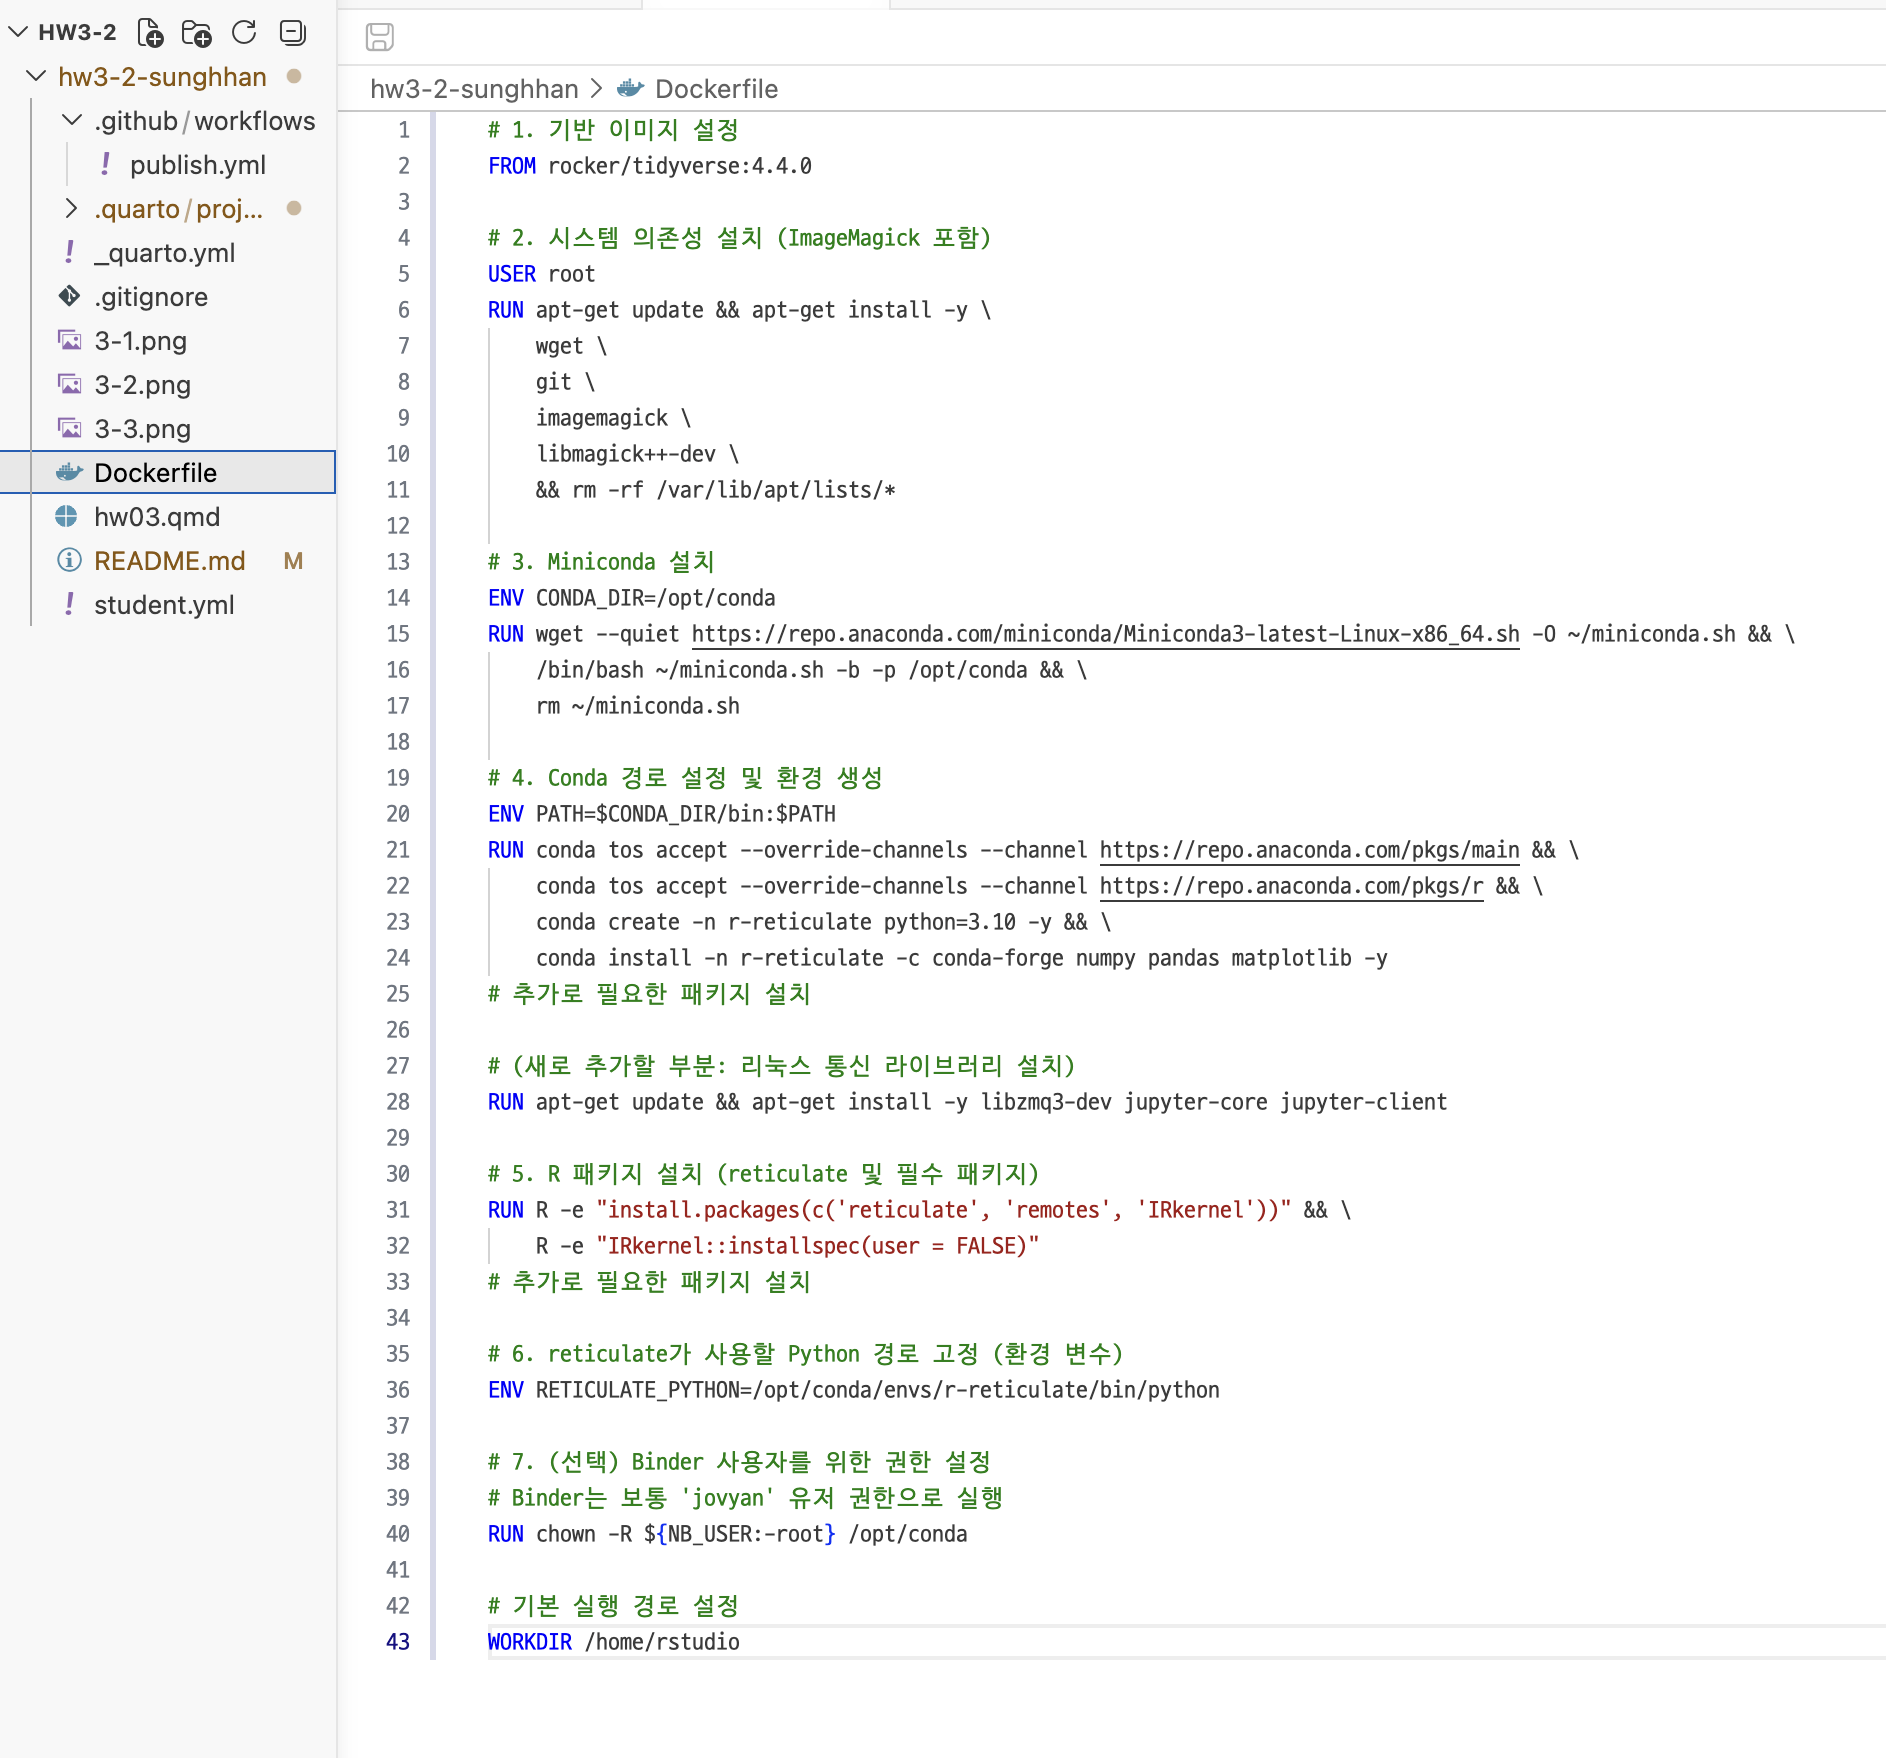

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

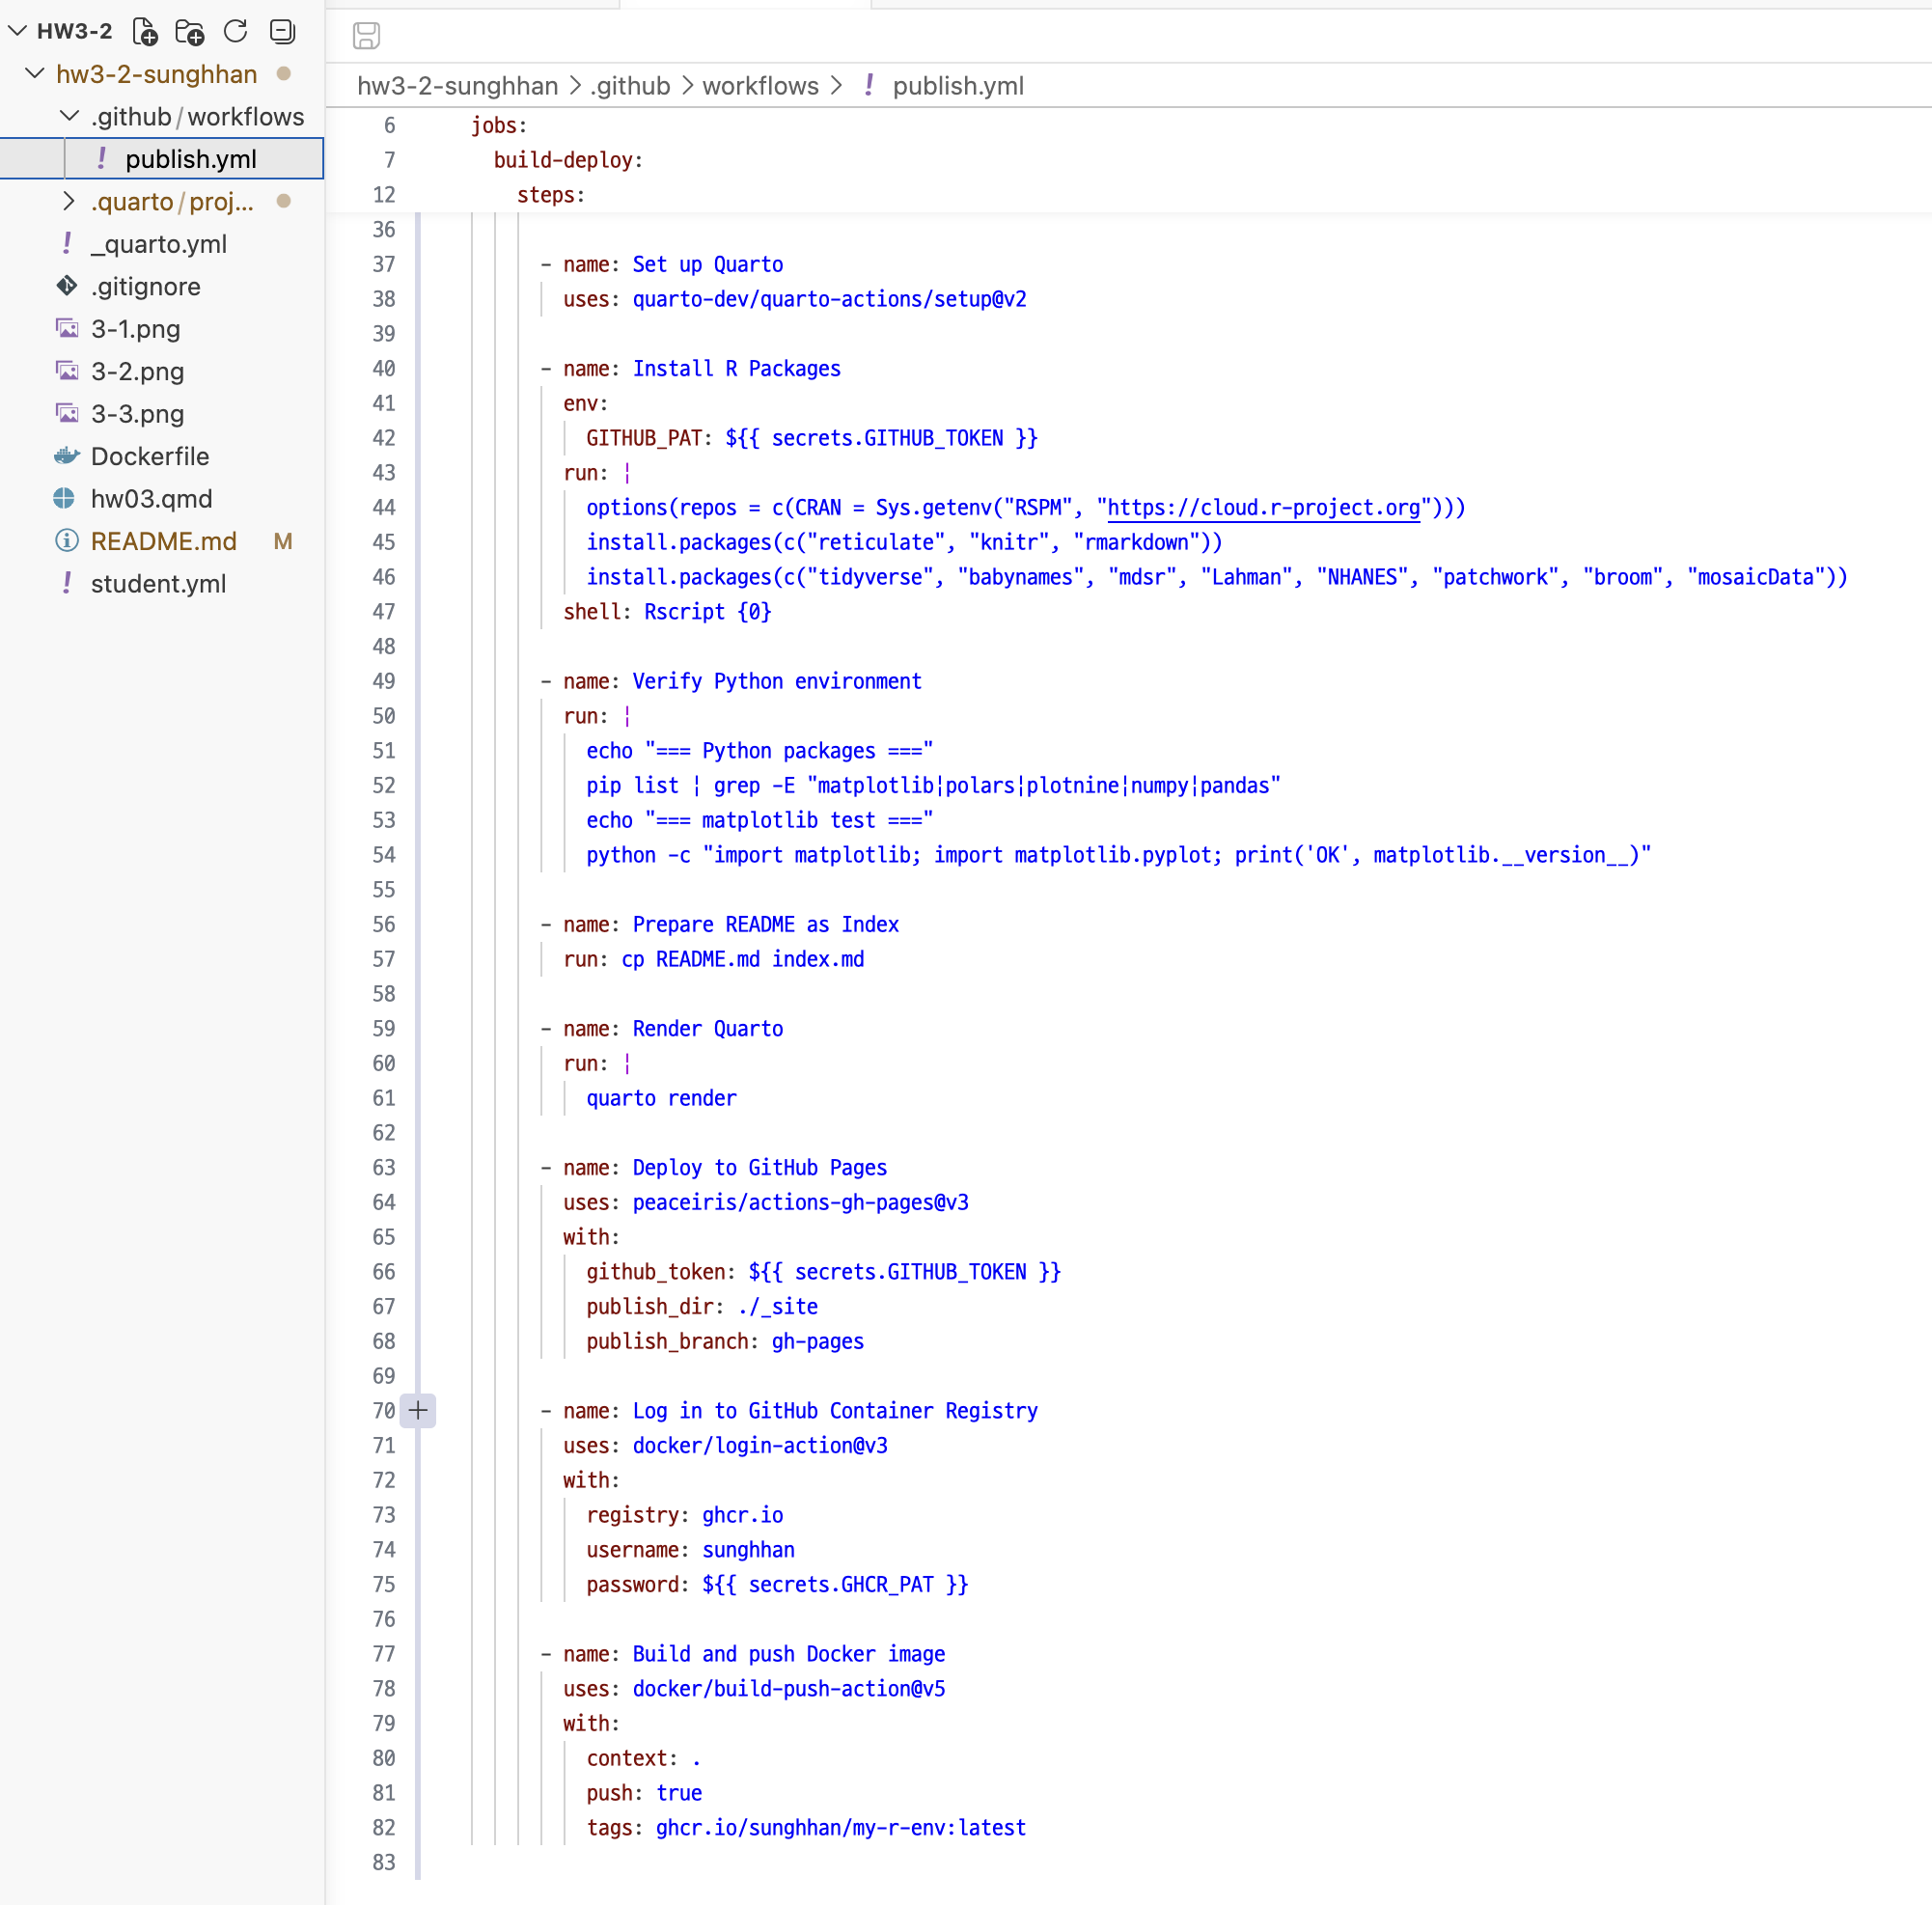

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/ghcr/<유저명>/my-r-env/latest?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

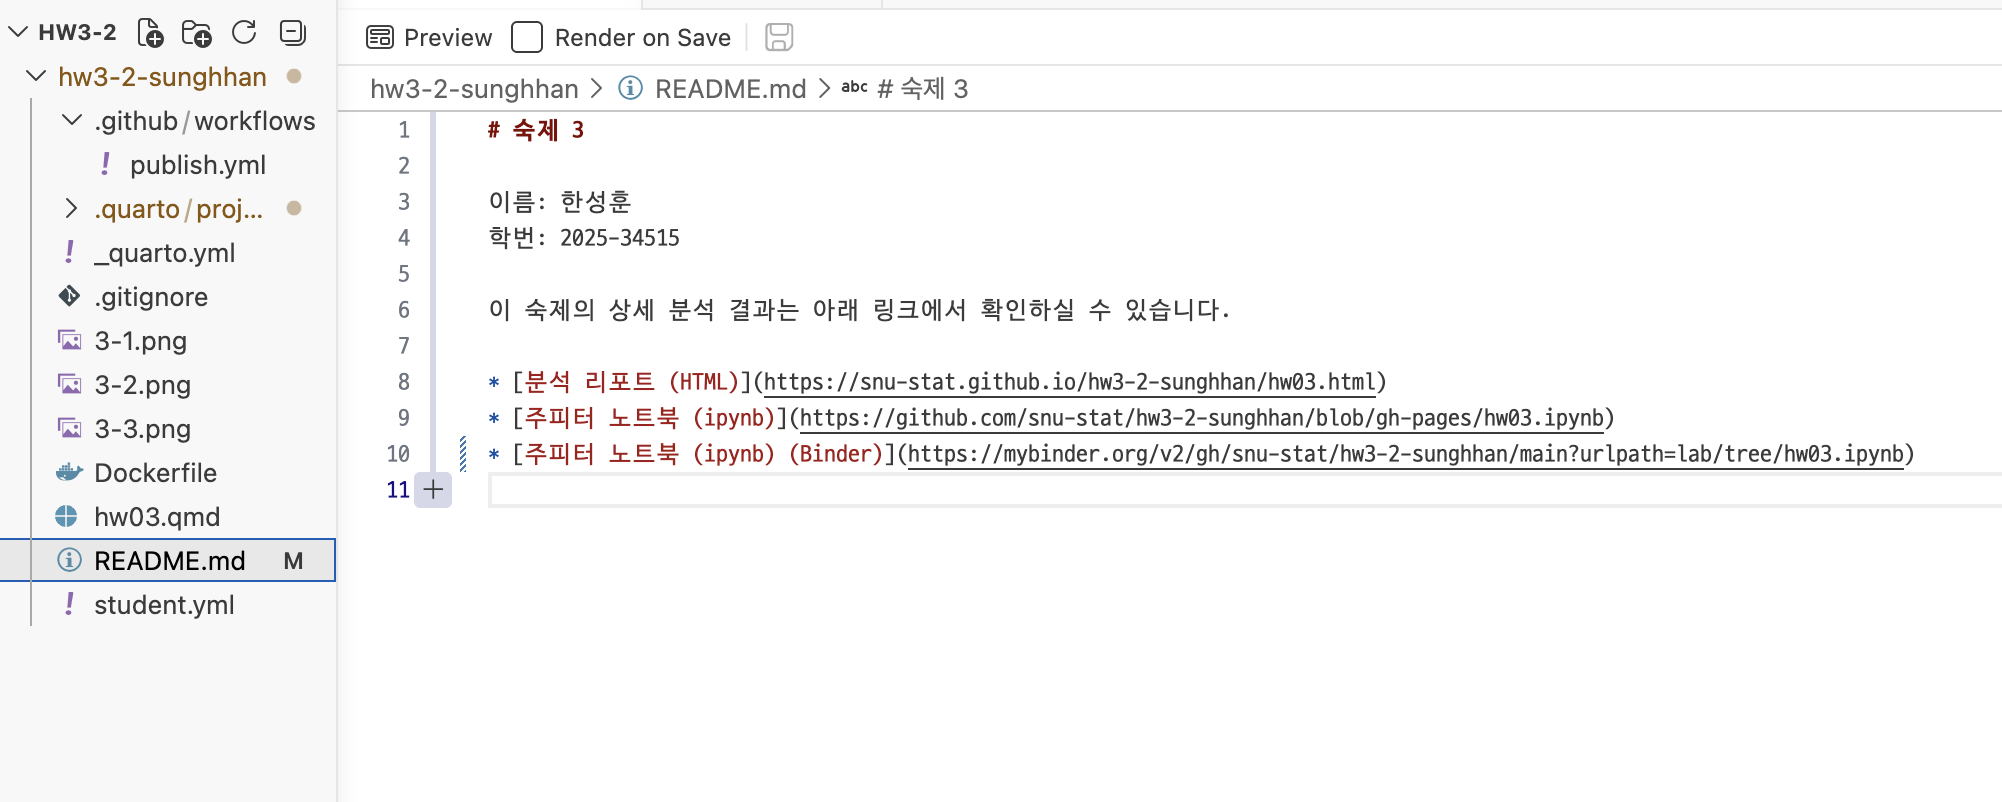